# Import Liabraries

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import torch.nn as nn
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F


# import warnings
import warnings
warnings.filterwarnings("ignore")

# We will use some methods from the sklearn module
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [ ]:
df = pd.DataFrame(pd.read_excel("32768 Education Data - Speed Motor.xlsx")) 
df.head()

In [ ]:
df.info()

In [ ]:
df.shape

In [ ]:
df.columns

In [ ]:
df.describe()

In [ ]:
print(df.corr())

In [ ]:
# Check Missing Values
df.isnull().sum().sort_values(ascending = False)

In [ ]:
X = df.iloc[:, :-1]
y = df[['Speed Motor']]

In [ ]:
X.head()

In [ ]:
y.head()

In [ ]:
# Get unique values
unique_values = df[['Speed Motor']].value_counts().index.values

print(unique_values)

# Exploratory Data Analysis

In [ ]:
# Distribution of the target variable
sns.distplot(df['Speed Motor']);

# Relationship of speed-motor with other variables

In [ ]:
sns.pairplot(df, x_vars=['a1', 'a2', 'a3', 'a4', 'a5'], y_vars='Speed Motor', height=4, aspect=1, kind='scatter')
plt.show()

In [ ]:
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')
plt.show()

In [ ]:
X_train,X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [ ]:
y_train.shape

In [ ]:
y_test.shape

In [ ]:
reg_model = linear_model.LinearRegression()

reg_model = LinearRegression().fit(X_train, y_train)

#Printing the model coefficients
print('Intercept: ',reg_model.intercept_)
list(zip(X, reg_model.coef_))


In [ ]:
#Predicting the Test and Train set result 
y_pred= reg_model.predict(X_test)  
x_pred= reg_model.predict(X_train) 

print("Prediction for test set: {}".format(y_pred))

In [ ]:
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
r2 = np.sqrt(metrics.mean_squared_error(y_test, y_pred))

print('Mean Absolute Error:', mae)
print('Mean Square Error:', mse)
print('Root Mean Square Error:', r2)

# Train with Neural Network

In [2]:
class MotorSpeedModel(nn.Module):
    def __init__(self, dropout_probability=0.5):
        super(MotorSpeedModel, self).__init__()
        self.fc1 = nn.Linear(5, 64) # 5 features to 64 hidden units
        self.fc2 = nn.Linear(64, 128) 
        self.fc3 = nn.Linear(128, 64) 
        self.fc4 = nn.Linear(64, 1) # 64 hidden units to 1 output

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x

In [3]:
# Load and preprocess the dataset
df = pd.DataFrame(pd.read_excel("32768 Education Data - Speed Motor.xlsx"))
X = df.iloc[:, :-1]
y = df[['Speed Motor']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [4]:
# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert y_train and y_test to numpy arrays and reshape
y_train = y_train.values.reshape(-1, 1)
y_test = y_test.values.reshape(-1, 1)


In [5]:
# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

In [6]:
# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [7]:
model = MotorSpeedModel()

# Define loss function and optimizer
criterion = nn.MSELoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5) 

In [8]:
train_losses = []
test_accuracies = []

num_epochs = 300
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for inputs, targets in train_loader:
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Evaluate the model
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            outputs = model(inputs)
            predicted = outputs.round()
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

    # Calculate accuracy
    accuracy = 100 * correct / total
    test_accuracies.append(accuracy)

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_train_loss:.4f}, Accuracy: {accuracy:.2f}%')

Epoch [10/300], Loss: 85.7602, Accuracy: 5.10%
Epoch [20/300], Loss: 15.0448, Accuracy: 18.05%
Epoch [30/300], Loss: 10.3580, Accuracy: 24.26%
Epoch [40/300], Loss: 7.0316, Accuracy: 29.92%
Epoch [50/300], Loss: 4.9682, Accuracy: 32.87%
Epoch [60/300], Loss: 4.0151, Accuracy: 39.88%
Epoch [70/300], Loss: 3.3715, Accuracy: 44.20%
Epoch [80/300], Loss: 2.5741, Accuracy: 46.67%
Epoch [90/300], Loss: 1.7444, Accuracy: 50.64%
Epoch [100/300], Loss: 1.1390, Accuracy: 56.87%
Epoch [110/300], Loss: 0.7894, Accuracy: 62.24%
Epoch [120/300], Loss: 0.6144, Accuracy: 73.60%
Epoch [130/300], Loss: 0.4970, Accuracy: 78.12%
Epoch [140/300], Loss: 0.4164, Accuracy: 84.21%
Epoch [150/300], Loss: 0.3634, Accuracy: 87.85%
Epoch [160/300], Loss: 0.3356, Accuracy: 89.67%
Epoch [170/300], Loss: 0.3123, Accuracy: 91.07%
Epoch [180/300], Loss: 0.2970, Accuracy: 90.95%
Epoch [190/300], Loss: 0.2766, Accuracy: 92.40%
Epoch [200/300], Loss: 0.2616, Accuracy: 92.39%
Epoch [210/300], Loss: 0.2561, Accuracy: 92.89%

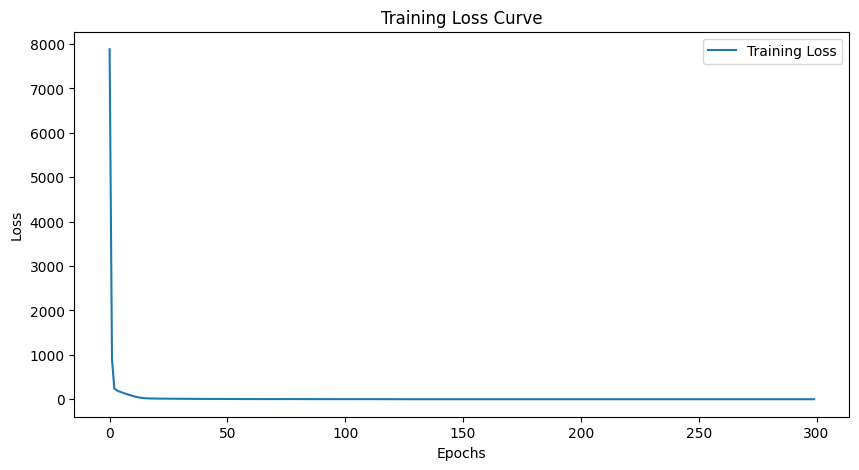

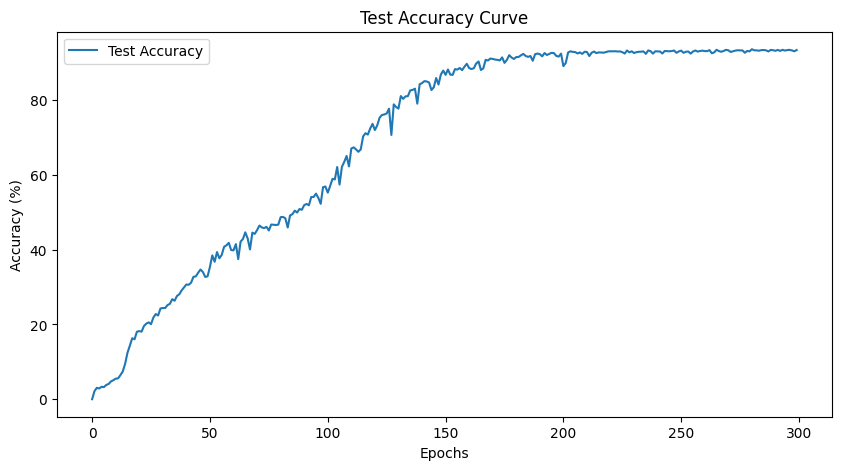

In [9]:
# Plotting the training loss curve
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.show()

# Plotting the test accuracy curve
plt.figure(figsize=(10, 5))
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Test Accuracy Curve')
plt.legend()
plt.show()

# Save Model

In [10]:
model_path = 'MotorSpeedModel.pth'
torch.save(model.state_dict(), model_path)
print(f'Model saved to {model_path}')

Model saved to MotorSpeedModel.pth


# Load Model and test it

In [12]:
input_dim = X_train.shape[1]

model = MotorSpeedModel(input_dim)
model.load_state_dict(torch.load('MotorSpeedModel.pth'))
model.eval()

MotorSpeedModel(
  (fc1): Linear(in_features=5, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (fc4): Linear(in_features=64, out_features=1, bias=True)
)

In [26]:
new_input_features = [75, 125, 125, 0, 175]
new_input_features = scaler.transform([new_input_features])  # Standardize the new input
new_input_tensor = torch.tensor([new_input_features], dtype=torch.float32)

with torch.no_grad():
    model.eval()  # Set the model to evaluation mode
    prediction = model(new_input_tensor)

predicted_value = prediction.item()

print("Predicted value:", predicted_value)

Predicted value: 75.72632598876953


c:\Users\abhar\.conda\envs\mvision\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
